# Data Curation Pipeline

This notebook prepares the two raw datasets used throughout my CM3070 Final Project. For each dataset it loads the raw public data, explores it to check quality and distributions, then filters it down to the technical and professional learning scope that matches my target users.

The two sources are:
- **Coursera 2021** — 623 courses and 1.45M reviews
- **Goodbooks-10K** — 10,000 books and 6M ratings

The notebook outputs four CSV files that every later notebook loads: the filtered courses, the filtered reviews, the filtered books, and the filtered ratings.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded")

Libraries loaded


---
## Loading and filtering the Coursera courses
The raw catalogue covers every subject area, including many outside my project scope. I filter using a keyword list built around the six domains my target users study: data and AI, programming, cloud and IT, business and finance, design, and career skills. A course is kept if its title matches any keyword.

In [2]:
# Load Coursera courses and filter to tech/professional ones
courses = pd.read_csv('Coursera_courses.csv')
print(f"Original number of courses: {len(courses)}")

# Keywords describing the target audience's interests
tech_keywords = [
    # Data and AI
    'data', 'machine learning', 'deep learning', 'artificial intelligence',
    r'\bai\b', 'statistics', 'analytics', 'analysis', 'neural',
    'natural language', 'computation', 'quantitative', 'modeling',
    # Programming
    'python', 'java', 'javascript', 'programming', 'coding', 'software',
    'web develop', 'html', 'css', 'sql', 'database', 'algorithm',
    'computer', 'tensorflow', 'pytorch', 'r programming',
    # Cloud, IT, security
    'cloud', 'aws', 'azure', 'devops', 'kubernetes', 'docker',
    'cyber', 'security', 'network', 'linux', 'operating system',
    'system administration', 'infrastructure', 'agile', 'technical',
    # Business and finance
    'business', 'marketing', 'finance', 'financial', 'accounting',
    'economics', 'manag', 'leadership', 'project', 'product',
    'excel', 'strategy', 'entrepreneur', 'startup', 'investment',
    'negotiat', 'sales', 'equity',
    # Design
    'design', 'ux', 'user experience', 'visual', 'graphic',
    # Career skills
    'productivity', 'learning how to learn', 'communication',
    'professional', 'career', 'team', 'engineer',
]

# Combine keywords into one regex and filter
pattern = '|'.join(tech_keywords)
tech_mask = courses['name'].str.contains(pattern, case=False, na=False, regex=True)
tech_courses = courses[tech_mask].copy()

print(f"Courses retained: {len(tech_courses)}")
print(f"Retention rate: {len(tech_courses) / len(courses) * 100:.1f}%")
print("\nFirst 10 courses kept:")
print(tech_courses[['name', 'institution']].head(10).to_string(index=False))

Original number of courses: 623
Courses retained: 336
Retention rate: 53.9%

First 10 courses kept:
                                                    name               institution
                                        Machine Learning       Stanford University
                          Technical Support Fundamentals                    Google
Become a CBRS Certified Professional Installer by Google Google - Spectrum Sharing
                                       Financial Markets           Yale University
 Programming for Everybody (Getting Started with Python)    University of Michigan
               The Bits and Bytes of Computer Networking                    Google
                                         AI For Everyone           DeepLearning.AI
                                  Crash Course on Python                    Google
                       Neural Networks and Deep Learning           DeepLearning.AI
                                   What is Data Science?              

---
## Exploring the raw courses table
Before moving on, I check the raw table for missing values, duplicates, and which institutions dominate the catalogue.

In [3]:
# Data quality checks on the raw courses table
print("Data types:")
print(courses.dtypes)

print(f"\nMissing values per column:")
print(courses.isnull().sum())

print(f"\nDuplicate rows: {courses.duplicated().sum()}")
print(f"Duplicate course_ids: {courses['course_id'].duplicated().sum()}")
print(f"Unique institutions: {courses['institution'].nunique()}")

print(f"\nTop 10 institutions by number of courses:")
print(courses['institution'].value_counts().head(10).to_string())

Data types:
name           object
institution    object
course_url     object
course_id      object
dtype: object

Missing values per column:
name           0
institution    0
course_url     0
course_id      0
dtype: int64

Duplicate rows: 0
Duplicate course_ids: 0
Unique institutions: 134

Top 10 institutions by number of courses:
institution
University of Pennsylvania                    43
University of Michigan                        31
Duke University                               24
Google Cloud                                  22
IBM                                           18
Stanford University                           18
University of Illinois at Urbana-Champaign    17
University of Virginia                        17
Yale University                               17
DeepLearning.AI                               16


---
## Filtering the reviews to the retained courses
Any review whose course is not in the retained set is dropped, so the reviews table stays consistent with the courses table.

In [4]:
# Filter reviews to the kept courses
print("Loading Coursera reviews...")
reviews = pd.read_csv('Coursera_reviews.csv')
print(f"Total reviews loaded: {len(reviews):,}")

tech_course_ids = set(tech_courses['course_id'])
tech_reviews = reviews[reviews['course_id'].isin(tech_course_ids)].copy()

print(f"Reviews retained: {len(tech_reviews):,}")
print(f"Retention rate: {len(tech_reviews) / len(reviews) * 100:.1f}%")
print(f"Unique reviewers: {tech_reviews['reviewers'].nunique():,}")
print(f"\nRating distribution:")
print(tech_reviews['rating'].value_counts().sort_index())

Loading Coursera reviews...
Total reviews loaded: 1,454,711
Reviews retained: 1,019,660
Retention rate: 70.1%
Unique reviewers: 203,891

Rating distribution:
rating
1     13389
2     12769
3     37844
4    172135
5    783523
Name: count, dtype: int64


---
## Exploring the raw reviews table
The reviews table drives the collaborative filtering model later in the project, so I check its missing values, rating spread, and how sparse the user-item matrix is.

In [5]:
# Data quality checks on the raw reviews table
print("Missing values per column:")
print(reviews.isnull().sum())

print(f"\nRating distribution:")
rating_counts = reviews['rating'].value_counts().sort_index()
print(rating_counts.to_string())
print(f"\nShare of 5-star reviews: {rating_counts[5] / len(reviews) * 100:.1f}%")

n_users = reviews['reviewers'].nunique()
n_items = reviews['course_id'].nunique()
sparsity = 100 * (1 - len(reviews) / (n_users * n_items))

print(f"\nUnique reviewers: {n_users:,}")
print(f"Courses with reviews: {n_items:,}")
print(f"User-item matrix sparsity: {sparsity:.2f}%")

# Placeholder names used for deleted accounts
deleted = reviews['reviewers'].str.contains('Deleted', case=False, na=False).sum()
print(f"\nReviews from deleted/placeholder accounts: {deleted:,} ({deleted/len(reviews)*100:.1f}%)")

Missing values per column:
reviews         153
reviewers         0
date_reviews      0
rating            0
course_id         0
dtype: int64

Rating distribution:
rating
1      17354
2      16188
3      48303
4     226702
5    1146164

Share of 5-star reviews: 78.8%

Unique reviewers: 287,808
Courses with reviews: 604
User-item matrix sparsity: 99.16%

Reviews from deleted/placeholder accounts: 5,412 (0.4%)


> Three things stand out from this check:

- The only column with missing values is the review text (153 rows, 0.01%). The columns that matter for modelling — `reviewers`, `course_id`, and `rating` — are all complete, so no rows need to be dropped or imputed.
- The user-item matrix is 99.16% sparse and 78.8% of ratings are 5 stars. Both patterns are normal for platform review data and are worth noting, since a heavy positive skew makes it easy for any model to look accurate.
- 0.4% of reviews come from deleted accounts, which Coursera stores under placeholder names such as "By Deleted A". These aggregate many separate anonymous users under a single identifier, so they do not represent one real person's history.

---

In [6]:
# Save filtered Coursera data for later notebooks
tech_courses.to_csv('coursera_courses_filtered.csv', index=False)
tech_reviews.to_csv('coursera_reviews_filtered.csv', index=False)
print("Saved: coursera_courses_filtered.csv")
print("Saved: coursera_reviews_filtered.csv")

Saved: coursera_courses_filtered.csv
Saved: coursera_reviews_filtered.csv


---
## Loading and filtering the Goodbooks-10K data
The Goodbooks dataset comes in four files: books, ratings, a tag dictionary, and a book-tag mapping. Since the dataset has no subject field, I use the community tags to identify educational content: a book is kept if at least 500 users applied a tag matching my educational keyword list. The 500 threshold removes books tagged educational by only a handful of users.

In [7]:
# Load all 4 goodbooks files and keep books with educational tags
tags = pd.read_csv('tags.csv')
book_tags = pd.read_csv('book_tags.csv')
books = pd.read_csv('books.csv')
ratings = pd.read_csv('ratings.csv')
print(f"Original books: {len(books):,}")
print(f"Original ratings: {len(ratings):,}")

# Keywords for educational, professional, and popular science books
edu_keywords = [
    'non-fiction', 'nonfiction',
    'business', 'self-help', 'self-improvement', 'productivity',
    'psychology', 'philosophy', 'economics',
    'computer-science', 'programming', 'technology', 'tech',
    'mathematics', 'science', 'engineering', 'statistics',
    'data', 'design', 'finance', 'management', 'leadership',
    'entrepreneur', 'startup', 'marketing',
]

# Find tag IDs matching educational keywords
edu_pattern = '|'.join(edu_keywords)
edu_tags = tags[tags['tag_name'].str.contains(edu_pattern, case=False, na=False)]
print(f"Educational tag IDs identified: {len(edu_tags)}")

# Sum how many times each book was tagged as educational
edu_book_tags = book_tags[book_tags['tag_id'].isin(edu_tags['tag_id'])]
book_edu_score = (
    edu_book_tags
    .groupby('goodreads_book_id')['count']
    .sum()
    .reset_index()
    .rename(columns={'count': 'edu_score'})
)

# Keep books where 500+ users applied an educational tag
THRESHOLD = 500
edu_book_ids = book_edu_score[book_edu_score['edu_score'] >= THRESHOLD]
educational_books = books.merge(edu_book_ids, on='goodreads_book_id', how='inner')
print(f"Books passing educational threshold: {len(educational_books):,}")

Original books: 10,000
Original ratings: 5,976,479
Educational tag IDs identified: 871
Books passing educational threshold: 1,394


---
## Exploring the raw Goodbooks data
I check the books and ratings tables for missing values and rating spread, and look at which tags are applied most often across the whole dataset.

In [8]:
# Data quality checks on the raw books and ratings tables
print("Books table — missing values:")
print(books[['title', 'authors', 'average_rating', 'goodreads_book_id']].isnull().sum())

print(f"\nBooks: {len(books):,}")
print(f"Ratings: {len(ratings):,}")
print(f"Unique users: {ratings['user_id'].nunique():,}")

print(f"\nRating distribution:")
print(ratings['rating'].value_counts().sort_index().to_string())

n_users_b = ratings['user_id'].nunique()
n_items_b = ratings['book_id'].nunique()
sparsity_b = 100 * (1 - len(ratings) / (n_users_b * n_items_b))
print(f"\nUser-item matrix sparsity: {sparsity_b:.2f}%")

print(f"\nTotal tags available: {len(tags):,}")
print(f"\nTop 15 most-applied tags:")
top_tags = (
    book_tags.groupby('tag_id')['count'].sum()
    .reset_index()
    .merge(tags, on='tag_id')
    .nlargest(15, 'count')[['tag_name', 'count']]
)
print(top_tags.to_string(index=False))

Books table — missing values:
title                0
authors              0
average_rating       0
goodreads_book_id    0
dtype: int64

Books: 10,000
Ratings: 5,976,479
Unique users: 53,424

Rating distribution:
rating
1     124195
2     359257
3    1370916
4    2139018
5    1983093

User-item matrix sparsity: 98.88%

Total tags available: 34,252

Top 15 most-applied tags:
          tag_name     count
           to-read 140718761
 currently-reading   7507958
         favorites   4503173
           fiction   3688819
           fantasy   3548157
       young-adult   1848306
          classics   1756920
       books-i-own   1317235
           romance   1231926
             owned   1224279
                ya    898334
           mystery    872282
       non-fiction    857901
historical-fiction    815421
            series    782637


---
## Removing books where fiction tagging dominates
The educational tag filter still lets through popular novels that happen to carry a few educational tags. I therefore compare each book's educational tag count against its fiction tag count, and keep only the books where the educational score is at least as high.

In [9]:
# Remove books where fiction tagging dominates educational tagging
fiction_keywords = [
    'fiction', 'novel', 'fantasy', 'sci-fi', 'science-fiction',
    'romance', 'thriller', 'mystery', 'horror', 'ya-fiction',
    'young-adult-fiction',
]

fiction_pattern = '|'.join(fiction_keywords)
fiction_tags = tags[tags['tag_name'].str.contains(fiction_pattern, case=False, na=False)]

# Sum how many times each book was tagged as fiction
fiction_scores = (
    book_tags[book_tags['tag_id'].isin(fiction_tags['tag_id'])]
    .groupby('goodreads_book_id')['count']
    .sum()
    .reset_index()
    .rename(columns={'count': 'fiction_score'})
)

# Add fiction score to each book, then keep only books where edu >= fiction
educational_books = educational_books.merge(fiction_scores, on='goodreads_book_id', how='left')
educational_books['fiction_score'] = educational_books['fiction_score'].fillna(0)
educational_books_clean = educational_books[
    educational_books['edu_score'] >= educational_books['fiction_score']
].copy()
print(f"Books retained after fiction filter: {len(educational_books_clean):,}")

# Filter ratings to the surviving books
edu_ratings = ratings[ratings['book_id'].isin(educational_books_clean['book_id'])].copy()
print(f"Ratings retained: {len(edu_ratings):,}")
print(f"Unique users retained: {edu_ratings['user_id'].nunique():,}")

# Show top 10 books retained
print("\nTop 10 educational books retained:")
top_books = (
    educational_books_clean
    .sort_values('edu_score', ascending=False)
    [['title', 'authors', 'average_rating', 'edu_score', 'fiction_score']]
    .head(10)
)
print(top_books.to_string(index=False))

Books retained after fiction filter: 698
Ratings retained: 264,276
Unique users retained: 37,882

Top 10 educational books retained:
                                                                       title                                  authors  average_rating  edu_score  fiction_score
                                        The Immortal Life of Henrietta Lacks                           Rebecca Skloot            4.04      15437          12248
              The Tipping Point: How Little Things Can Make a Big Difference                         Malcolm Gladwell            3.92      15175           8858
                               Blink: The Power of Thinking Without Thinking                         Malcolm Gladwell            3.89      14963           8670
                                                     A Brief History of Time Stephen Hawking, Cao Chi, Phạm Văn Thiều            4.12      12597           5745
                                  Stiff: The Curious Lives of Human

## Removing off-scope non-fiction

The top titles above show that the fiction filter alone was not enough. Because the educational filter accepts any book carrying a non-fiction tag, books from religion, poetry, memoir, and biography are still being retained — categories outside the technical and professional learning scope of my target users.

I therefore apply a second exclusion filter using the same scoring approach as the fiction filter: each book's off-scope tag count is compared against its educational tag count, and the book is dropped if off-scope tagging dominates.

In [10]:
# Remove books dominated by off-scope non-fiction categories
offscope_keywords = [
    'religion', 'religious', 'christian', 'christianity', 'spiritual',
    'faith', 'theology', 'bible', 'islam', 'buddhis',
    'poetry', 'poems', 'memoir', 'biography', 'autobiograph',
    'true-crime', 'travel', 'food', 'cooking', 'sports',
    'humor', 'humour', 'comedy', 'parenting', 'grief',
]

offscope_pattern = '|'.join(offscope_keywords)
offscope_tags = tags[tags['tag_name'].str.contains(offscope_pattern, case=False, na=False)]

# Sum how many times each book was tagged as off-scope
offscope_scores = (
    book_tags[book_tags['tag_id'].isin(offscope_tags['tag_id'])]
    .groupby('goodreads_book_id')['count']
    .sum()
    .reset_index()
    .rename(columns={'count': 'offscope_score'})
)

# Add off-scope score, then keep only books where edu >= off-scope
educational_books_clean = educational_books_clean.merge(
    offscope_scores, on='goodreads_book_id', how='left'
)
educational_books_clean['offscope_score'] = educational_books_clean['offscope_score'].fillna(0)
educational_books_clean = educational_books_clean[
    educational_books_clean['edu_score'] >= educational_books_clean['offscope_score']
].copy()

print(f"Books retained after off-scope filter: {len(educational_books_clean):,}")

# Re-filter ratings to the surviving books
edu_ratings = ratings[ratings['book_id'].isin(educational_books_clean['book_id'])].copy()
print(f"Ratings retained: {len(edu_ratings):,}")
print(f"Unique users retained: {edu_ratings['user_id'].nunique():,}")

print("\nTop 10 books after the off-scope filter:")
print(
    educational_books_clean
    .sort_values('edu_score', ascending=False)
    [['title', 'authors', 'average_rating', 'edu_score', 'offscope_score']]
    .head(10)
    .to_string(index=False)
)

Books retained after off-scope filter: 593
Ratings retained: 217,744
Unique users retained: 34,974

Top 10 books after the off-scope filter:
                                                                       title                                  authors  average_rating  edu_score  offscope_score
                                        The Immortal Life of Henrietta Lacks                           Rebecca Skloot            4.04      15437          2941.0
              The Tipping Point: How Little Things Can Make a Big Difference                         Malcolm Gladwell            3.92      15175             0.0
                               Blink: The Power of Thinking Without Thinking                         Malcolm Gladwell            3.89      14963             0.0
                                                     A Brief History of Time Stephen Hawking, Cao Chi, Phạm Văn Thiều            4.12      12597             0.0
                                  Stiff: The Curious L

In [11]:
# Save filtered books data and print final dataset summary
educational_books_clean.to_csv('books_filtered.csv', index=False)
edu_ratings.to_csv('ratings_filtered.csv', index=False)
print("Saved: books_filtered.csv")
print("Saved: ratings_filtered.csv")

print("\n" + "=" * 60)
print("FINAL CURATED DATASETS")
print("=" * 60)
print(f"\nCoursera (online courses):")
print(f"  Courses retained: {len(tech_courses):,}")
print(f"  Reviews retained: {len(tech_reviews):,}")
print(f"  Unique reviewers: {tech_reviews['reviewers'].nunique():,}")

print(f"\ngoodbooks-10k (educational books):")
print(f"  Books retained:   {len(educational_books_clean):,}")
print(f"  Ratings retained: {len(edu_ratings):,}")
print(f"  Unique users:     {edu_ratings['user_id'].nunique():,}")

total = len(tech_reviews) + len(edu_ratings)
print(f"\nCombined user-item interactions: {total:,}")

Saved: books_filtered.csv
Saved: ratings_filtered.csv

FINAL CURATED DATASETS

Coursera (online courses):
  Courses retained: 336
  Reviews retained: 1,019,660
  Unique reviewers: 203,891

goodbooks-10k (educational books):
  Books retained:   593
  Ratings retained: 217,744
  Unique users:     34,974

Combined user-item interactions: 1,237,404


---
## Comparing the two raw datasets

Both datasets record user ratings on a 1-5 scale. This chart compares their raw distributions, which explains a modelling challenge that appears later: both skew heavily toward positive ratings.

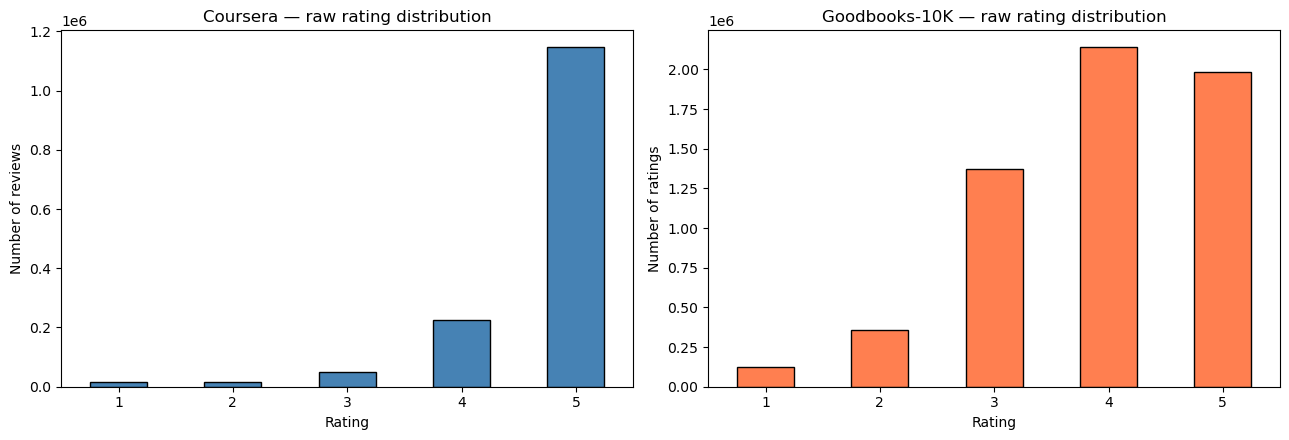

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Coursera raw ratings
reviews['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Coursera — raw rating distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of reviews')
axes[0].set_xticklabels([1, 2, 3, 4, 5], rotation=0)

# Goodbooks raw ratings
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='black'
)
axes[1].set_title('Goodbooks-10K — raw rating distribution')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Number of ratings')
axes[1].set_xticklabels([1, 2, 3, 4, 5], rotation=0)

plt.tight_layout()
plt.show()

## Summary of the curation

The exploration confirmed four things that shape the modelling work later in the project:

1. Both datasets skew heavily toward positive ratings, so a model that always predicts a high rating will look deceptively accurate. Comparing each model against a baseline on the same data is therefore more informative than the absolute error values.
2. Both user-item matrices are extremely sparse, which is the standard condition for collaborative filtering and motivates the content-based model that follows.
3. The Coursera reviews contain placeholder names for deleted accounts, which aggregate many anonymous users into one identifier. These are excluded when selecting sample users for qualitative testing.
4. Tag-based filtering for the books required two stages. The educational threshold and fiction filter alone retained 698 books, but inspection showed religion, poetry, and memoir titles among them. Adding an off-scope exclusion filter brought the catalogue to 593 books.

The four filtered files saved by this notebook are the inputs for every later stage of the project.